# Research Notebook Week 3
## Ferdinand Soong

# 1: Experience

The goal of this week was creating a Python class for calculating the gas density $\rho_{gas}$ and projected gas density $\rho_{proj}$. This class was then used in MCMC simulations to determine the best values for the variables M200, rm, rho0, c and Upsilon. 

## Motivation:
With the best-fit values of all parameters, the final model can be compared to the observational data, and a $\chi^2$ value can be calculated to evaluate how well the model describes the data.



# 2: What? (What happened?)
## Describe what happened during your activities for the week.
The class did not differ much from the previous code for the density profile except being more tidy and efficient. It only uses the spherical profile and uses the jeans built in mass calculation. The unit conversion from G in the final step has been adjusted and another part for calculating the projected gas density and chi^2 has been added. Since the biggest time consumption comes from calculating the projected gas density many appraoches were tried to shorten the time. These include quad, trapezoid and lastly a geospace approach which proved the most reliable and time efficient with calculating even at smaller radii. (The quad or even trapezoid approach might prove just as efficient when looking at larger starting radii than 10^-2)
# code chi^2
    def chi2_projection(self, R_obs, proj_obs, err_obs, R_model):
    # Compute model projection
        proj_model = self.compute_projection(R_model)

    # Interpolate model at observed points
        model_interp = interp1d(
            R_model,
            proj_model,
            bounds_error=False,
            fill_value=np.nan
        )
        model_vals = model_interp(R_obs)

    # Mask NaNs
        mask = (
            np.isfinite(model_vals)
            & np.isfinite(proj_obs)
            & np.isfinite(err_obs)
    )

    # Compute chi^2
        chi2 = np.sum(((proj_obs[mask] - model_vals[mask]) / err_obs[mask])**2)
        return chi2

# code projected gas density
    def compute_projection(self, R_values):
        rmax=self.rmax
        proj = np.zeros(len(R_values))
        eps = 0.01
        num=100


        for i, R in enumerate(R_values):

            if R >= rmax:
                proj[i] = 0.0
                continue

            # log-spaced grid close to R
            r_int = R + np.geomspace(eps, rmax - R, num)

            rho_vals = self.rho_interp(r_int)

            integrand = 2 * r_int * rho_vals**2 / np.sqrt(r_int**2 - R**2)

            proj[i] = np.trapezoid(integrand, r_int)

        return proj

When running the MCMC only few walkers (20) and steps (500) were used since even with the improved code the MCMC took a significant amount of time to run. 
Here are the results for the Galaxy N533:
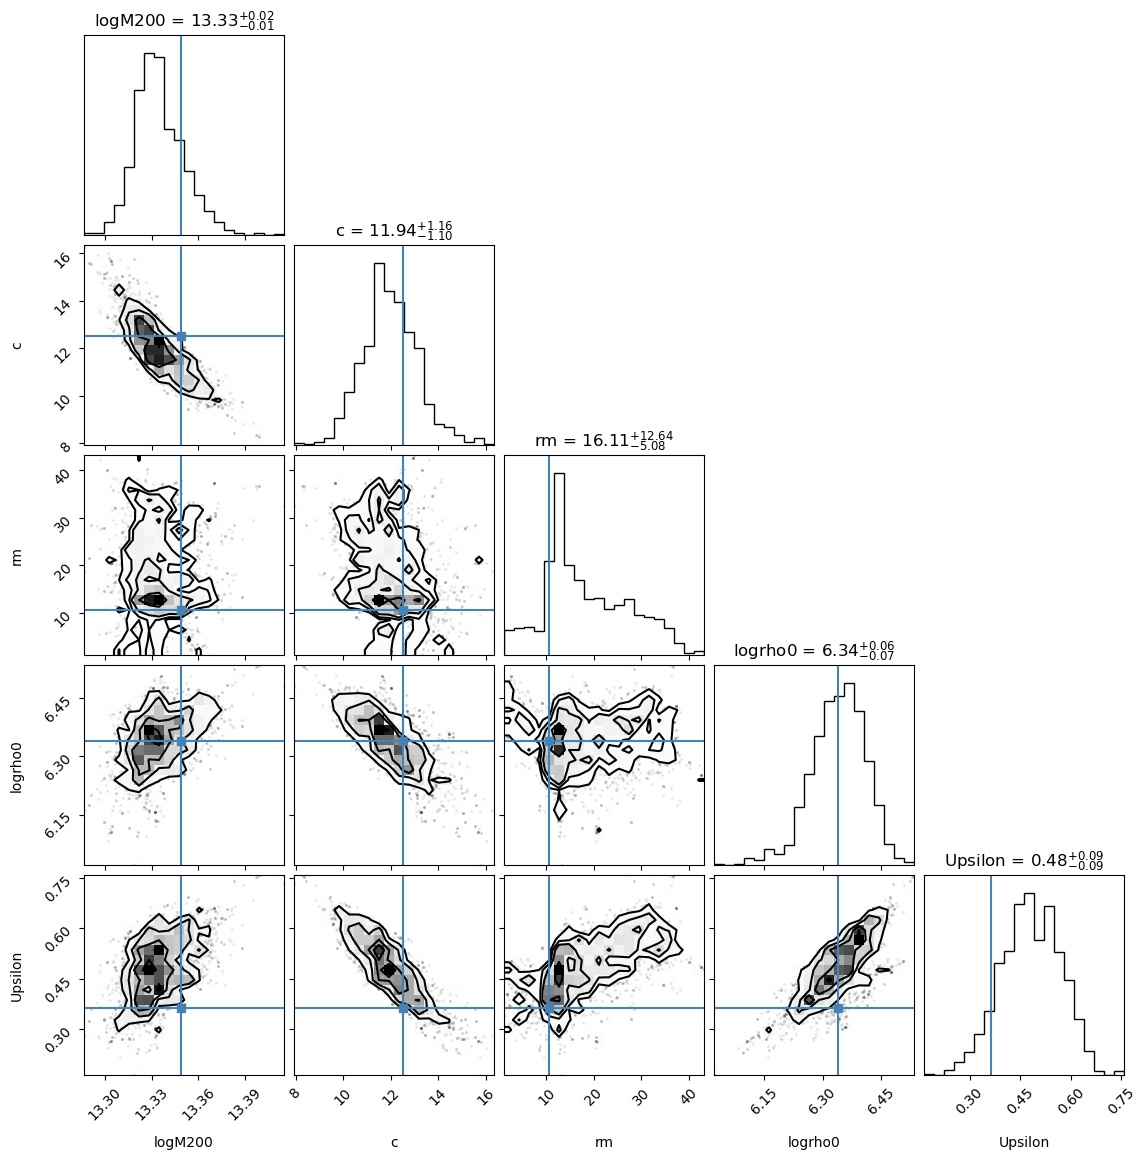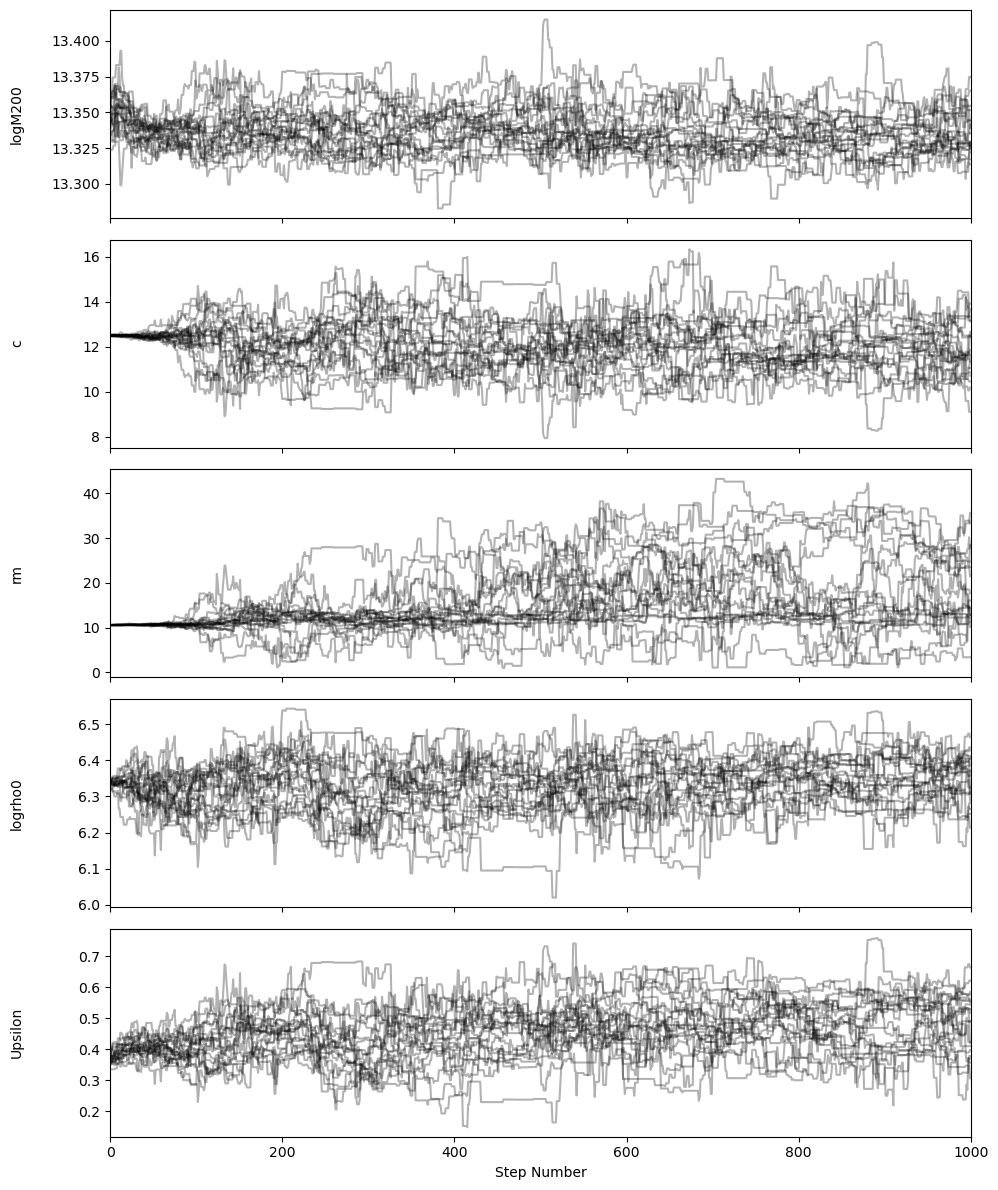

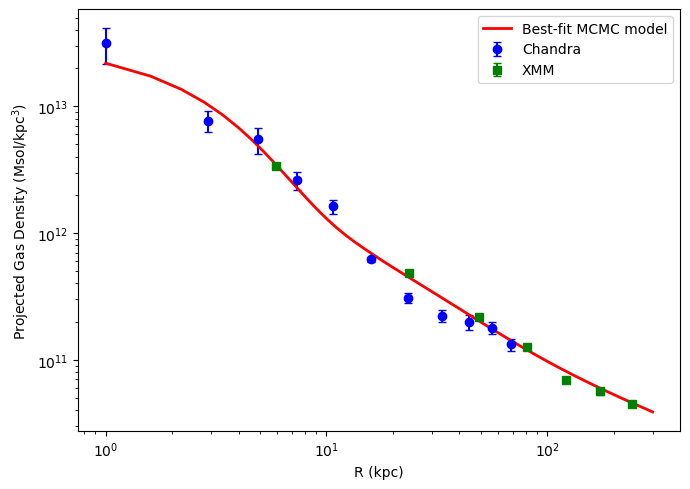

# 3: So what? (What does it mean?)
## Describe your results

The results match the observation data very well with a reduced chi^2 of 6.25. This trend is shared with most of the galaxies for the gastadello paper, although some exhibit a very low values of Upsilon, with the lowest being around 0.1. Others show a reduced chi^2 of over 40. This is often the case for galaxies with very limited observational data. 

# 4. Now what? (What's next?)
## Plan for the next week

The next steps could be to run the MCMC again while no longer assuming a spherical galaxy but an elliptic one and see if the data also matches or even looks better than our previous approximation. One could also check more galaxies outside of the Gastadello paper with a broader dataset to see if the low Upsilon values come from having to little data about the galaxy or if something else is the cause. Another approach would be to take a look at the different rm values and the cross section of the DM particles  since the MCMC seems to give multiple possible rm values for some galaxies.

# 5. Bibliography

MAPPING THE DARK MATTER IN THE NGC 5044 GROUP WITH ROSAT: EVIDENCE FOR A NEARLY HOMOGENEOUS COOLING FLOW WITH A COOLING WAKE
LAURENCE P. DAVID, CHRISTINE JONES, AND WILLIAM FORMAN

AN ANALYTICAL MODEL FOR SPHERICAL GALAXIES AND BULGES
Lars Hernquist

PROBING THE DARK MATTER AND GAS FRACTION IN RELAXED GALAXY GROUPS WITH X-RAY
OBSERVATIONS FROM Chandra AND XMM
Fabio Gastaldello1 et al.